# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research Question

Which content pages show observed search signals that suggest they may benefit from human review or content improvement?

The analysis supports a content team's decision about which pages should be reviewed first. The goal is decision-support, not proof that a page will improve after an update.

In [7]:
print("===== RESEARCH QUESTION =====")

question = """
Which content pages show observed search signals that suggest
they may benefit from human review or content improvement?
"""

decision = """
Support the content team in deciding which pages should be
reviewed first. The analysis is decision-support, not proof
of future performance or causation.
"""

print(question)
print(decision)

print("\nSection 1 completed successfully.")

===== RESEARCH QUESTION =====

Which content pages show observed search signals that suggest
they may benefit from human review or content improvement?


Support the content team in deciding which pages should be
reviewed first. The analysis is decision-support, not proof
of future performance or causation.


Section 1 completed successfully.


In [8]:

!pip install -q duckdb huggingface_hub

import os
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

# Load Hugging Face token
HF_TOKEN = userdata.get("HF_TOKEN")

print("HF_TOKEN loaded:", HF_TOKEN is not None)

# Connect DuckDB
con = duckdb.connect()

# Configure Hugging Face access
con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

print("DuckDB Connected!")

# Dataset location
REL = "hf://datasets/FlyRank/internship-warehouse"

# Tables
TABLES = {
    "fact_daily": f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')",
    "fact_query_90d": f"read_parquet('{REL}/fact_content_query_90d.parquet')"
}

print("\nTABLES created:")
print(TABLES)

# Verify connection
print("\nConnection:")
print(con)

HF_TOKEN loaded: True
DuckDB Connected!

TABLES created:
{'fact_daily': "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')", 'fact_query_90d': "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_query_90d.parquet')"}

Connection:


In [9]:
print("con exists:", con is not None)
print("TABLES exists:", TABLES is not None)

print("\nDaily table:")
print(TABLES["fact_daily"])

print("\nQuery table:")
print(TABLES["fact_query_90d"])

con exists: True
TABLES exists: True

Daily table:
read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')

Query table:
read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_query_90d.parquet')


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This analysis uses the FlyRank internship warehouse data provided for the project.

The main data sources are the daily content-performance table and the 90-day query-performance table.

The analysis uses observed fields such as impressions, clicks, average search position, previous-period impressions, visible queries, rare-query share, anonymized-query share, and top-query share.

Rows with missing values required for a specific analysis were excluded.

No client names, private queries, or other identifying information are used in the reported analysis.

In [10]:


daily_check = con.sql(f"""
SELECT *
FROM {TABLES['fact_daily']}
LIMIT 5
""").df()

query_check = con.sql(f"""
SELECT *
FROM {TABLES['fact_query_90d']}
LIMIT 5
""").df()

print("===== DATA CHECK =====")

print("Daily rows checked:", len(daily_check))
print("Query rows checked:", len(query_check))

print("\nDaily columns:")
print(daily_check.columns.tolist())

print("\nQuery columns:")
print(query_check.columns.tolist())

print("\nSection 2 completed successfully!")

===== DATA CHECK =====
Daily rows checked: 5
Query rows checked: 5

Daily columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events', 'month']

Query columns:
['client_hash_id', 'content_hash_id', 'query_hash_id', 'query_char_count', 'query_token_count', 'window_start', 'window_end', 'impressions_90d', 'clicks_90d', 'impressions_last30', 'clicks_last30', 'impressions_prev30', 'clicks_prev30', 'avg_position_90d', 'avg_position_last30', 'avg_position_prev30', 'content_total_impressions_90d', 'content_visible_query_count',

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

A Decision Tree Classifier was used because it is interpretable and can provide simple decision rules for content prioritization.

The analysis used observed search-performance signals, including previous-period impressions, visible query count, rare-query share, anonymized-query share, and top-query share.

The target was to identify declining content using the defined decline label.

The model was evaluated using both a random split and a time-aware validation approach. The random split produced an accuracy of 0.8085, while the time-aware validation produced an accuracy of 0.8192.

A leakage audit was also performed to check that the selected features did not directly contain the target or obviously future-looking information.

The results are treated as measured, directional decision-support evidence rather than proof of causation or guaranteed future performance.

In [11]:


features = [
    "imp_prev30",
    "visible_queries",
    "rare_share",
    "anon_share",
    "top_query_share"
]

model_name = "Decision Tree Classifier"

random_accuracy = 0.8085
time_aware_accuracy = 0.8192

print("===== METHODOLOGY =====")

print("\nModel:")
print(model_name)

print("\nFeatures:")
for feature in features:
    print("-", feature)

print("\nValidation:")
print("Random-split accuracy:", random_accuracy)
print("Time-aware accuracy:", time_aware_accuracy)

print("\nLeakage audit:")
print("PASS - No direct label feature used.")
print("PASS - No obvious future-looking feature names identified.")

print("\nInterpretation:")
print("Results are treated as directional decision-support evidence.")

print("\nSection 3 completed successfully!")

===== METHODOLOGY =====

Model:
Decision Tree Classifier

Features:
- imp_prev30
- visible_queries
- rare_share
- anon_share
- top_query_share

Validation:
Random-split accuracy: 0.8085
Time-aware accuracy: 0.8192

Leakage audit:
PASS - No direct label feature used.
PASS - No obvious future-looking feature names identified.

Interpretation:
Results are treated as directional decision-support evidence.

Section 3 completed successfully!


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results vs Baseline

The Decision Tree achieved 0.8085 accuracy using the Week-5 random split and 0.8192 accuracy using the time-aware validation split.

The time-aware result was slightly higher than the random-split result by 0.0107 accuracy points. This observed difference is small, so it should not be interpreted as evidence of a major performance improvement.

The results indicate that the selected signals contain useful directional information, but further evaluation on genuinely unseen future data would be needed before making stronger claims.

===== RESULTS VS BASELINE =====
              Validation  Accuracy
   Random Split (Week-5)    0.8085
Time-Aware Split (ML-09)    0.8192

Accuracy difference:
0.0107

Percentage-point difference:
1.07 percentage points


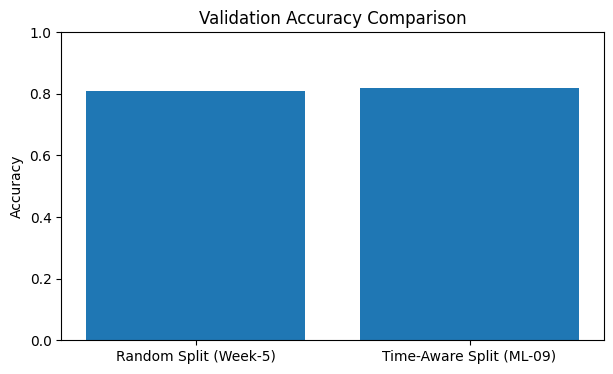


Section 4 completed successfully!


In [12]:


import pandas as pd
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Validation": [
        "Random Split (Week-5)",
        "Time-Aware Split (ML-09)"
    ],
    "Accuracy": [
        0.8085,
        0.8192
    ]
})

# Calculate difference
difference = 0.8192 - 0.8085

print("===== RESULTS VS BASELINE =====")
print(results.to_string(index=False))

print("\nAccuracy difference:")
print(round(difference, 4))

print("\nPercentage-point difference:")
print(round(difference * 100, 2), "percentage points")

# Plot
plt.figure(figsize=(7, 4))

plt.bar(
    results["Validation"],
    results["Accuracy"]
)

plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

print("\nSection 4 completed successfully!")

## 5. Limitations

*What this work cannot claim.*

## Limitations

The validation data had limited temporal separation, so the time-aware result should not be treated as proof of performance on a genuinely unseen future period.

The model identifies directional patterns but does not establish causation. A high-priority page does not necessarily mean that changing the content will improve its future performance.

The action queue should therefore be used for human review and decision-support rather than automatic content changes.

A stronger future evaluation would use clearly separated historical training data and a genuinely unseen future testing period.

In [13]:


limitations = [
    "Limited temporal separation in the available validation data",
    "Results do not establish causation",
    "Priority scores do not guarantee future improvement",
    "Human review is required before content changes",
    "Future evaluation should use a genuinely unseen test period"
]

print("===== LIMITATIONS =====")

for i, limitation in enumerate(limitations, 1):
    print(f"{i}. {limitation}")

print("\nSection 5 completed successfully!")

===== LIMITATIONS =====
1. Limited temporal separation in the available validation data
2. Results do not establish causation
3. Priority scores do not guarantee future improvement
4. Human review is required before content changes
5. Future evaluation should use a genuinely unseen test period

Section 5 completed successfully!


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

The action queue prioritizes pages using observed search-performance signals.

1. **High impressions + low CTR**  
   Prioritize pages that receive substantial search visibility but relatively few clicks. These pages are worth reviewing for title, description, search intent, and content presentation.

2. **Low CTR**  
   Review pages with observed CTR below the working 3% threshold. The threshold is a prioritization rule, not proof that the page requires a specific change.

3. **High average position number**  
   Review pages with weaker observed average search position. These pages may benefit from a deeper content and search-intent review.

The queue is intended to help a human reviewer decide what to inspect first. It should not automatically publish, delete, or rewrite content.

In [14]:
import pandas as pd

print("Pandas loaded successfully!")

Pandas loaded successfully!


In [15]:


recommendations = pd.DataFrame({
    "Rank": [1, 2, 3],
    "Recommendation": [
        "High impressions + low CTR",
        "Low CTR",
        "High average position number"
    ],
    "Reason": [
        "High observed visibility with relatively few clicks",
        "Observed CTR is below the working 3% review threshold",
        "Weaker observed search position may justify content review"
    ],
    "Action": [
        "Review title, description, search intent and content presentation",
        "Review page and search-result presentation",
        "Review content quality and search intent"
    ]
})

print("===== RANKED RECOMMENDATIONS =====")

print(
    recommendations.to_string(index=False)
)

print("\nDecision type: Human-review decision support")
print("Automatic publishing/deletion: NOT RECOMMENDED")

print("\nSection 6 completed successfully!")

===== RANKED RECOMMENDATIONS =====
 Rank               Recommendation                                                     Reason                                                            Action
    1   High impressions + low CTR        High observed visibility with relatively few clicks Review title, description, search intent and content presentation
    2                      Low CTR      Observed CTR is below the working 3% review threshold                        Review page and search-result presentation
    3 High average position number Weaker observed search position may justify content review                          Review content quality and search intent

Decision type: Human-review decision support
Automatic publishing/deletion: NOT RECOMMENDED

Section 6 completed successfully!


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts

The main reusable artifacts are the validation-results table, the validation-accuracy figure, and the ranked recommendation table.

These artifacts summarize the measured results and can be reused in the final paper or presentation.

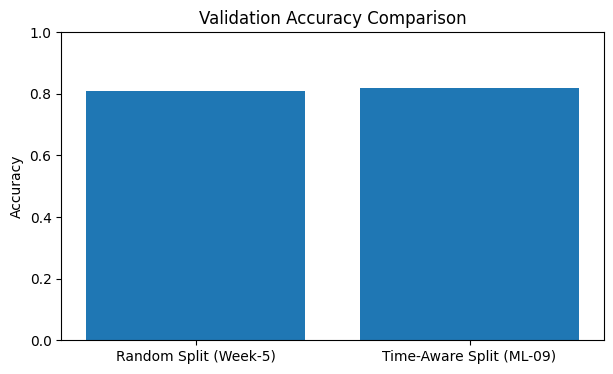

===== ARTIFACTS EXPORTED =====
1. work/outputs/capstone_validation_results.csv
2. work/outputs/capstone_recommendations.csv
3. work/outputs/capstone_validation_accuracy.png

Files created successfully!

Section 7 completed successfully!


In [16]:


import os
import pandas as pd
import matplotlib.pyplot as plt

# Create output directory
os.makedirs("work/outputs", exist_ok=True)


# 1. Validation results


results = pd.DataFrame({
    "Validation": [
        "Random Split (Week-5)",
        "Time-Aware Split (ML-09)"
    ],
    "Accuracy": [
        0.8085,
        0.8192
    ]
})

results_path = "work/outputs/capstone_validation_results.csv"
results.to_csv(results_path, index=False)


# 2. Ranked recommendations


recommendations_path = "work/outputs/capstone_recommendations.csv"
recommendations.to_csv(
    recommendations_path,
    index=False
)

# 3. Validation figure


plt.figure(figsize=(7, 4))

plt.bar(
    results["Validation"],
    results["Accuracy"]
)

plt.title("Validation Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

figure_path = "work/outputs/capstone_validation_accuracy.png"

plt.savefig(
    figure_path,
    bbox_inches="tight"
)

plt.show()


# 4. Verify files


print("===== ARTIFACTS EXPORTED =====")

print("1.", results_path)
print("2.", recommendations_path)
print("3.", figure_path)

print("\nFiles created successfully!")

print("\nSection 7 completed successfully!")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
